# Alternative Sentiment Scores

## Overview

This notebook demonstrates `score_sentiment_features` from `alternative_sentiment_scores` using observed financial news.

- Problem: observed news can include recurring scanner and list articles that dilute article-level sentiment features.
- Approach: exclude low-signal URL categories, compute FinBERT sentiment features for the retained articles, and summarize their distribution and daily trend.

## Observed Data

This cell loads the observed news dataset produced by `alternative_data` and defines the sentiment-feature output settings.

- `data_root` identifies the alternative-data directory at `../../data/research_data/alternative`.
- `symbol_slug` identifies the instrument in source and output file names.
- `period_slug` identifies the inclusive observation period in source and output file names.
- `data_path` identifies the observed-news Parquet file.
- `feature_dir` identifies the sentiment-feature output directory.
- `alternative_data` contains the observed news rows.
- `id` contains the source article identifier.
- `headline` contains the article title.
- `source` identifies the publisher.
- `url` contains the article link used for category selection.
- `summary` contains the article summary used for sentiment scoring.
- `created_at` contains the UTC publication time.
- `updated_at` contains the UTC update time.
- `symbols` contains the comma-separated related instruments.
- `author` identifies the article author.
- `content` contains the article body.

In [1]:
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data_preprocessing.alternative_sentiment_scores import score_sentiment_features

data_root = Path("../../data/research_data/alternative")
symbol_slug = "aapl"
period_slug = "2025-01-01_2025-12-31"
data_path = data_root / "data" / f"{symbol_slug}_{period_slug}.parquet"
feature_dir = data_root / "features"

alternative_data = pd.read_parquet(data_path)

display(alternative_data.head())
alternative_data.shape

,id,headline,source,url,summary,created_at,updated_at,symbols,author,content
0,42755273,EXCLUSIVE: Top 20 Most-Searched Tickers On Ben...,benzinga,https://www.benzinga.com/trading-ideas/25/01/4...,Each trading day features hundreds of headline...,2025-01-01 14:15:41+00:00,2025-01-01 14:15:42+00:00,"AAPL,AMD,AVGO,BTCUSD,CLSK,DELL,DJT,LAES,LLY,MS...",Chris Katje,<p>Each trading day features hundreds of headl...
1,42755470,Competitor Analysis: Evaluating Apple And Comp...,benzinga,https://www.benzinga.com/insights/news/25/01/4...,,2025-01-01 15:00:27+00:00,2025-01-01 15:00:28+00:00,AAPL,Benzinga Insights,<p>In the ever-evolving and intensely competit...
2,42756523,10 Information Technology Stocks With Whale Al...,benzinga,https://www.benzinga.com/insights/options/25/0...,,2025-01-01 17:35:14+00:00,2025-01-01 17:35:15+00:00,"AAPL,DELL,INTC,MSFT,MSTR,MU,NVDA,RGTI,SOUN,WULF",Benzinga Insights,<p>This whale alert can help traders discover ...
3,42756619,"Warren Buffett Says Buy S&P 500, But This Tech...",benzinga,https://www.benzinga.com/markets/25/01/4275661...,Venture capitalist Chamath Palihapitiya has qu...,2025-01-01 18:00:19+00:00,2025-01-01 18:00:19+00:00,"AAPL,MSFT,NVDA",Bibhu Pattnaik,<p>Venture capitalist <strong>Chamath Palihapi...
4,42758055,"Tim Cook, Mark Zuckerberg, Elon Musk, And More...",benzinga,https://www.benzinga.com/25/01/42758055/tim-co...,"Top tech CEOs like Tim Cook, Sundar Pichai, El...",2025-01-02 02:28:01+00:00,2025-01-02 02:28:02+00:00,"AAPL,GOOG,GOOGL,META,TSLA",Ananya Gairola,"<p>As the world stepped into 2025, some of the..."


(3309, 10)

## URL-Based News Selection

This cell excludes recurring scanner, comparison, and list articles through their URL path categories and reports the retained rows.

- `url_paths` contains the lowercase path component parsed from each `url`.
- `excluded_url_prefixes` contains the URL path categories omitted from sentiment scoring.
- `excluded_url` identifies rows whose URL path starts with an excluded category.
- `meaningful_news` retains the original news columns and source order for rows outside the excluded categories.
- `excluded_by_prefix` reports each excluded URL prefix and its excluded row count.
- `url_prefix` identifies one excluded path category.
- `excluded_rows` reports how many observed rows belong to that category.
- `selection_summary` reports the observed, excluded, and retained row counts.
- `selection` identifies the selection stage.
- `row_count` reports the number of rows at that stage.
- The displayed article sample contains `created_at`, `headline`, and `url` for retained news.

In [2]:
url_paths = alternative_data["url"].map(
    lambda url: urlparse(url).path.lower(),
)
excluded_url_prefixes = (
    "/insights/options/",
    "/insights/news/",
    "/trading-ideas/",
)
excluded_url = url_paths.str.startswith(excluded_url_prefixes)
meaningful_news = alternative_data.loc[~excluded_url].reset_index(drop=True)

excluded_by_prefix = pd.DataFrame(
    {
        "url_prefix": excluded_url_prefixes,
        "excluded_rows": [
            url_paths.str.startswith(prefix).sum()
            for prefix in excluded_url_prefixes
        ],
    },
)
selection_summary = pd.DataFrame(
    {
        "row_count": [
            len(alternative_data),
            excluded_url.sum(),
            len(meaningful_news),
        ],
    },
    index=pd.Index(["observed", "excluded", "retained"], name="selection"),
)

assert len(alternative_data) == excluded_url.sum() + len(meaningful_news)
assert not meaningful_news["url"].map(
    lambda url: urlparse(url).path.lower(),
).str.startswith(excluded_url_prefixes).any()

display(excluded_by_prefix)
display(selection_summary)
display(meaningful_news[["created_at", "headline", "url"]].head())

,url_prefix,excluded_rows
0,/insights/options/,199
1,/insights/news/,256
2,/trading-ideas/,246


,row_count
selection,
observed,3309
excluded,701
retained,2608


,created_at,headline,url
0,2025-01-01 18:00:19+00:00,"Warren Buffett Says Buy S&P 500, But This Tech...",https://www.benzinga.com/markets/25/01/4275661...
1,2025-01-02 02:28:01+00:00,"Tim Cook, Mark Zuckerberg, Elon Musk, And More...",https://www.benzinga.com/25/01/42758055/tim-co...
2,2025-01-02 08:13:45+00:00,Apple Discounts iPhone 16 Prices In China By U...,https://www.benzinga.com/media/25/01/42759147/...
3,2025-01-02 11:22:23+00:00,UBS Cuts iPhone Sales Forecast For December Am...,https://www.benzinga.com/25/01/42760822/ubs-cu...
4,2025-01-02 13:09:29+00:00,Broadcom Thrives with 114% Stock Surge in AI B...,https://www.benzinga.com/media/25/01/42762874/...


## Sentiment Feature Table

This cell computes FinBERT sentiment features for every retained article, saves the model-specific feature table, and reports its leading rows.

- `batch_size` sets the number of retained articles scored in each model batch.
- `sentiment_features` retains every source-news field and adds the four derived sentiment fields.
- `sentiment_positive` contains the FinBERT positive-class probability.
- `sentiment_negative` contains the FinBERT negative-class probability.
- `sentiment_neutral` contains the FinBERT neutral-class probability.
- `sentiment_score` contains `sentiment_positive` minus `sentiment_negative`, so positive values indicate favorable language and negative values indicate unfavorable language.
- `sentiment_output_path` identifies the model-specific Parquet file in the alternative-feature directory.

In [3]:
batch_size = 16
sentiment_features = score_sentiment_features(
    meaningful_news,
    batch_size=batch_size,
)

score_difference = (
    sentiment_features["sentiment_positive"]
    - sentiment_features["sentiment_negative"]
    - sentiment_features["sentiment_score"]
).abs()
assert score_difference.dropna().lt(1e-12).all()

feature_dir.mkdir(parents=True, exist_ok=True)
sentiment_output_path = feature_dir / (
    f"{symbol_slug}_finbert_sentiment_scores_{period_slug}.parquet"
)
sentiment_features.to_parquet(sentiment_output_path, index=False)

print(sentiment_output_path)
display(sentiment_features.head())
sentiment_features.shape

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

../../data/research_data/alternative/features/aapl_finbert_sentiment_scores_2025-01-01_2025-12-31.parquet


,id,headline,source,url,summary,created_at,updated_at,symbols,author,content,sentiment_positive,sentiment_negative,sentiment_neutral,sentiment_score
0,42756619,"Warren Buffett Says Buy S&P 500, But This Tech...",benzinga,https://www.benzinga.com/markets/25/01/4275661...,Venture capitalist Chamath Palihapitiya has qu...,2025-01-01 18:00:19+00:00,2025-01-01 18:00:19+00:00,"AAPL,MSFT,NVDA",Bibhu Pattnaik,<p>Venture capitalist <strong>Chamath Palihapi...,0.024122,0.842134,0.133743,-0.818012
1,42758055,"Tim Cook, Mark Zuckerberg, Elon Musk, And More...",benzinga,https://www.benzinga.com/25/01/42758055/tim-co...,"Top tech CEOs like Tim Cook, Sundar Pichai, El...",2025-01-02 02:28:01+00:00,2025-01-02 02:28:02+00:00,"AAPL,GOOG,GOOGL,META,TSLA",Ananya Gairola,"<p>As the world stepped into 2025, some of the...",0.801017,0.013107,0.185875,0.787910
2,42759147,Apple Discounts iPhone 16 Prices In China By U...,benzinga,https://www.benzinga.com/media/25/01/42759147/...,Apple has introduced discounts of up to $68.50...,2025-01-02 08:13:45+00:00,2025-01-02 08:13:45+00:00,AAPL,Ananya Gairola,<p><strong>Apple Inc.</strong> (NASDAQ:<a clas...,0.734848,0.193763,0.071389,0.541085
3,42760822,UBS Cuts iPhone Sales Forecast For December Am...,benzinga,https://www.benzinga.com/25/01/42760822/ubs-cu...,After Apple Inc&#39;s market share fell in Chi...,2025-01-02 11:22:23+00:00,2025-01-02 11:22:24+00:00,AAPL,Rishabh Mishra,<p>After <strong>Apple Inc.&#8217;s</strong> (...,0.009226,0.971653,0.019121,-0.962428
4,42762874,Broadcom Thrives with 114% Stock Surge in AI B...,benzinga,https://www.benzinga.com/media/25/01/42762874/...,"In 2024, the U.S. tech sector had a tumultuous...",2025-01-02 13:09:29+00:00,2025-01-02 13:09:30+00:00,"AAPL,AMD,ARM,AVGO,GOOG,GOOGL,INTC,META,MSFT,NV...",Anusuya Lahiri,<p>The year 2024 proved very eventful for the ...,0.836527,0.050468,0.113005,0.786059


(2608, 14)

## Sentiment Score Distribution

This cell visualizes the distribution of article-level FinBERT sentiment scores.

- The horizontal axis represents `sentiment_score` from `-1` through `1`.
- The vertical axis reports the number of retained articles in each score interval.
- The vertical reference line at `0` separates unfavorable scores from favorable scores.

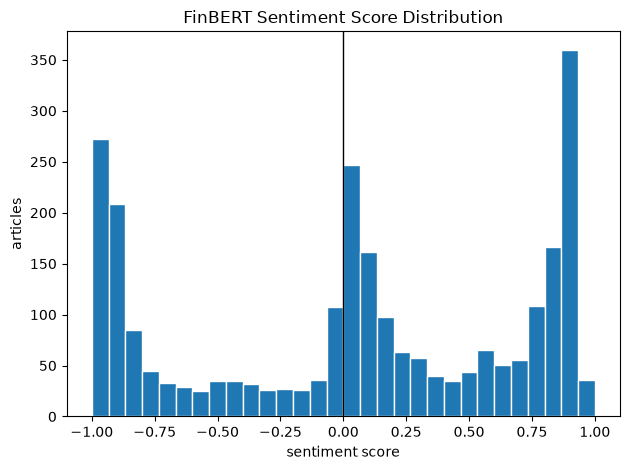

In [4]:
distribution_axis = sentiment_features["sentiment_score"].plot.hist(
    bins=30,
    range=(-1, 1),
    color="tab:blue",
    edgecolor="white",
)
distribution_axis.axvline(0, color="black", linewidth=1)
distribution_axis.set_xlabel("sentiment score")
distribution_axis.set_ylabel("articles")
distribution_axis.set_title("FinBERT Sentiment Score Distribution")
plt.tight_layout()
plt.show()

## Daily Sentiment Trend

This cell computes and visualizes the mean FinBERT sentiment score for each UTC publication date.

- `daily_sentiment` contains the mean `sentiment_score` for each UTC calendar day and retains missing values for dates without articles.
- The horizontal axis represents the UTC publication date.
- The vertical axis reports the daily mean `sentiment_score`.
- The horizontal reference line at `0` separates unfavorable daily means from favorable daily means.

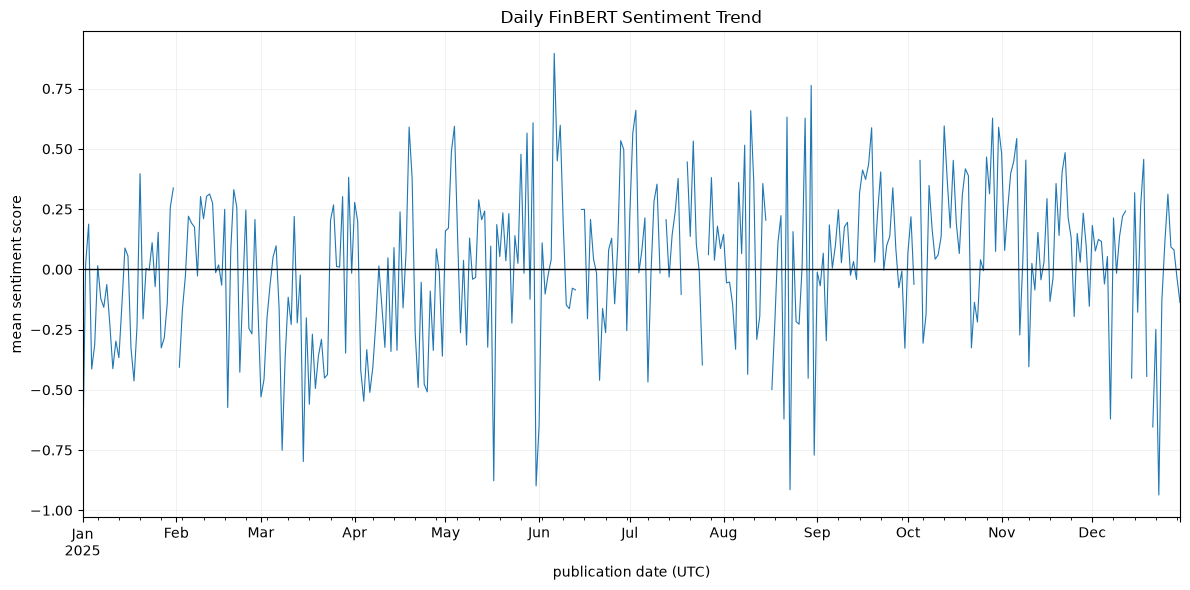

In [5]:
daily_sentiment = (
    sentiment_features.set_index("created_at")["sentiment_score"]
    .resample("D")
    .mean()
)

daily_axis = daily_sentiment.plot(
    figsize=(12, 6),
    color="tab:blue",
    linewidth=0.8,
)
daily_axis.axhline(0, color="black", linewidth=1)
daily_axis.set_xlabel("publication date (UTC)")
daily_axis.set_ylabel("mean sentiment score")
daily_axis.set_title("Daily FinBERT Sentiment Trend")
daily_axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()